<a href="https://colab.research.google.com/github/falyseck/Multimodel_Data_Prepocessing/blob/main/image_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/image_dataset"

In [ ]:
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Checking if images load correctly

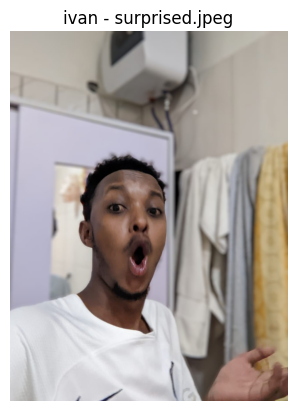

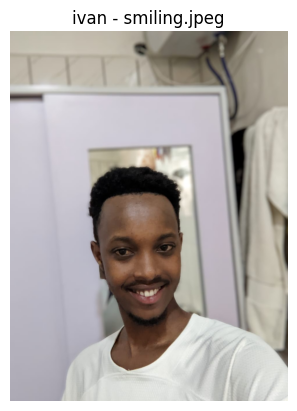

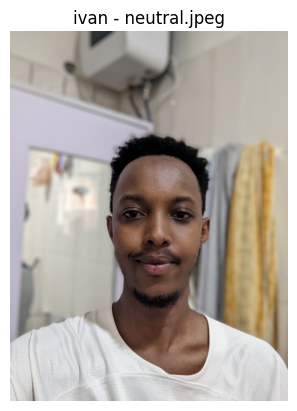

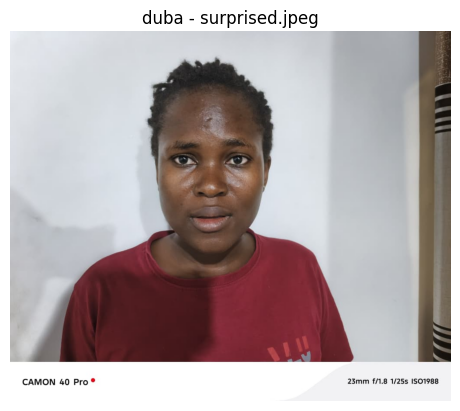

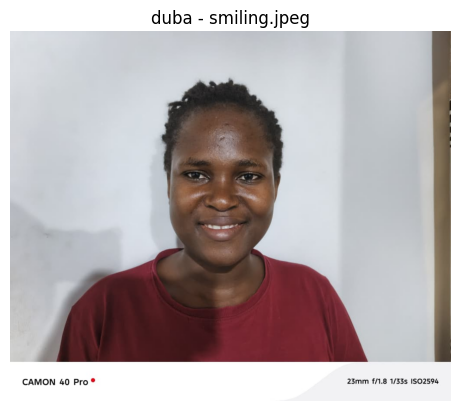

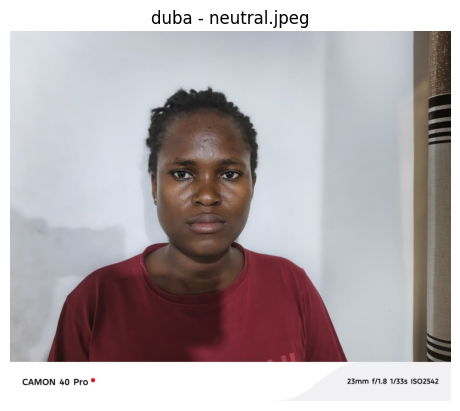

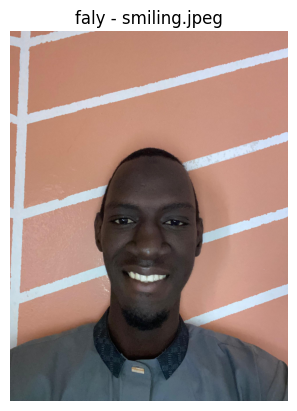

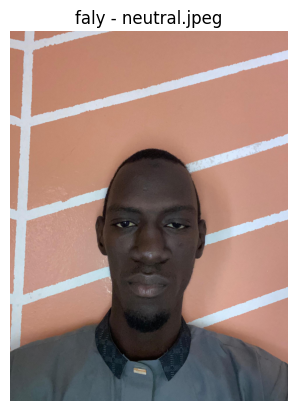

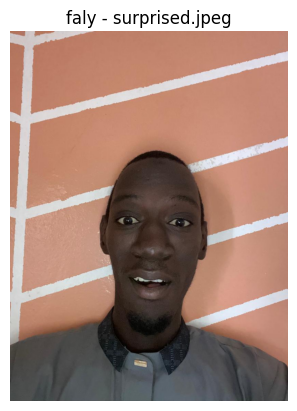

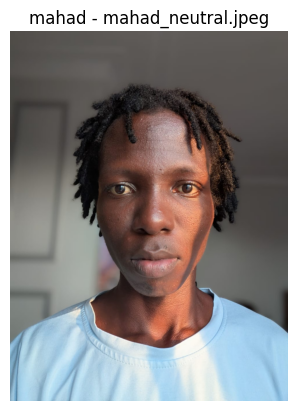

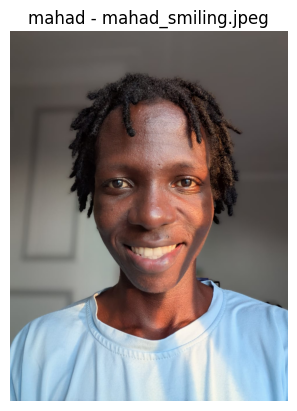

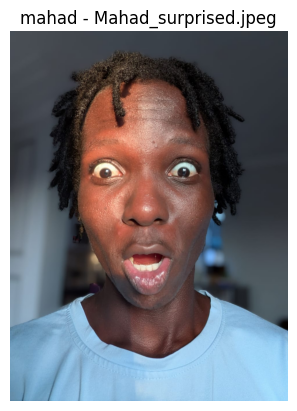

In [ ]:
for member in os.listdir(dataset_path):
    member_path = os.path.join(dataset_path, member)

    for image_name in os.listdir(member_path):
        image_path = os.path.join(member_path, image_name)

        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.imshow(img)
        plt.title(f"{member} - {image_name}")
        plt.axis("off")
        plt.show()

### Augmentation functions

In [ ]:
def rotate_image(image, angle=15):
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(image, M, (w, h))

def flip_image(image):
    return cv2.flip(image, -1)

def convert_gray(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

### Feature extraction function using histogram

In [ ]:
def extract_histogram(gray_image):
    hist = cv2.calcHist([gray_image], [0], None, [256], [0,256])
    hist = hist.flatten()
    return hist

### Main pipeline

In [ ]:
data = []

for member in os.listdir(dataset_path):

    member_path = os.path.join(dataset_path, member)

    for image_name in os.listdir(member_path):

        image_path = os.path.join(member_path, image_name)
        image = cv2.imread(image_path)

        # augmentations
        rotated = rotate_image(image)
        flipped = flip_image(image)

        images = [image, rotated, flipped]

        for img in images:

            gray = convert_gray(img)

            hist = extract_histogram(gray)

            row = [member, image_name] + hist.tolist()

            data.append(row)

### Saving features to csv

In [ ]:
columns = ["person", "image"] + [f"pixel_{i}" for i in range(256)]

df = pd.DataFrame(data, columns=columns)

df.to_csv("/content/drive/MyDrive/image_features.csv", index=False)

print("CSV file saved successfully!")

CSV file saved successfully!


In [ ]:
df.head()

,person,image,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,...,pixel_246,pixel_247,pixel_248,pixel_249,pixel_250,pixel_251,pixel_252,pixel_253,pixel_254,pixel_255
0,ivan,surprised.jpeg,400.0,1946.0,1953.0,1560.0,1431.0,955.0,820.0,761.0,...,501.0,289.0,60.0,37.0,13.0,7.0,6.0,4.0,2.0,0.0
1,ivan,surprised.jpeg,130418.0,1916.0,1940.0,1596.0,1488.0,970.0,827.0,804.0,...,503.0,289.0,54.0,23.0,9.0,4.0,4.0,1.0,0.0,0.0
2,ivan,surprised.jpeg,400.0,1946.0,1953.0,1560.0,1431.0,955.0,820.0,761.0,...,501.0,289.0,60.0,37.0,13.0,7.0,6.0,4.0,2.0,0.0
3,ivan,smiling.jpeg,3321.0,2768.0,2516.0,2212.0,2080.0,1674.0,1652.0,1511.0,...,140.0,115.0,91.0,109.0,112.0,133.0,164.0,178.0,254.0,364.0
4,ivan,smiling.jpeg,133318.0,2731.0,2538.0,2253.0,2064.0,1688.0,1667.0,1519.0,...,111.0,121.0,91.0,105.0,103.0,146.0,156.0,187.0,252.0,357.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Columns: 258 entries, person to pixel_255
dtypes: float64(256), object(2)
memory usage: 72.7+ KB


In [ ]:
df.columns

Index(['person', 'image', 'pixel_0', 'pixel_1', 'pixel_2', 'pixel_3',
       'pixel_4', 'pixel_5', 'pixel_6', 'pixel_7',
       ...
       'pixel_246', 'pixel_247', 'pixel_248', 'pixel_249', 'pixel_250',
       'pixel_251', 'pixel_252', 'pixel_253', 'pixel_254', 'pixel_255'],
      dtype='object', length=258)

### Visualize augmented images

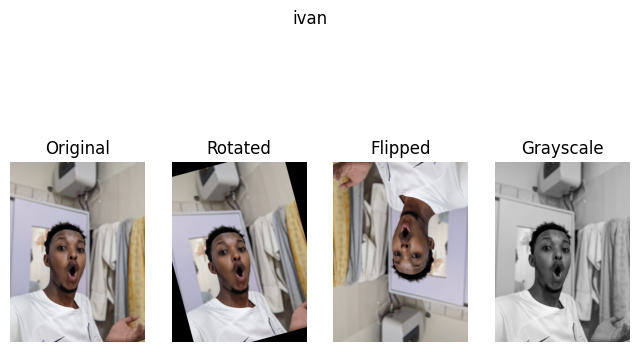

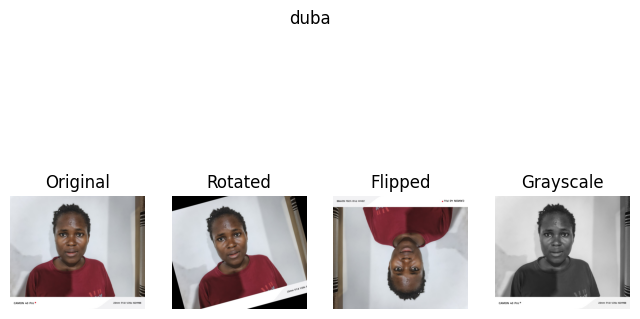

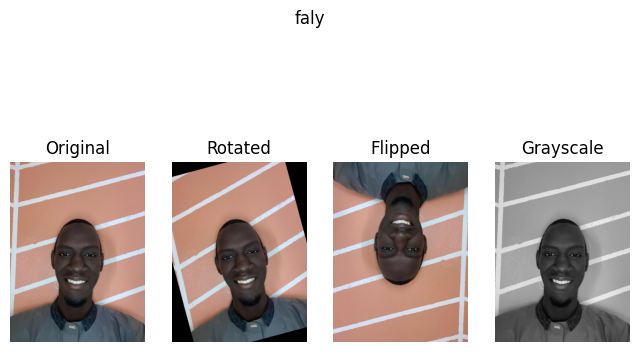

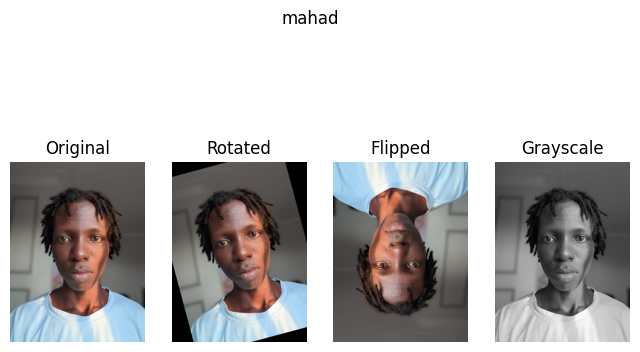

In [ ]:
for member in os.listdir(dataset_path):

    member_path = os.path.join(dataset_path, member)
    image_name = os.listdir(member_path)[0]

    image_path = os.path.join(member_path, image_name)
    img = cv2.imread(image_path)

    rotated = rotate_image(img)
    flipped = flip_image(img)
    gray = convert_gray(img)

    plt.figure(figsize=(8,5))

    plt.subplot(1,4,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
    plt.title("Rotated")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(cv2.cvtColor(flipped, cv2.COLOR_BGR2RGB))
    plt.title("Flipped")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(gray, cmap="gray")
    plt.title("Grayscale")
    plt.axis("off")

    plt.suptitle(member)
    plt.show()